In [1]:
# Patient Readmission Prediction

In [2]:
## Import libraries

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [4]:
## Data Profiling

In [5]:
df = pd.read_csv('Raw/diabetic_data.csv', na_values='?')
print(f"Shape: {df.shape}")
print(f"Columns: {df.columns.tolist()}")
df.head()

Shape: (101766, 50)
Columns: ['encounter_id', 'patient_nbr', 'race', 'gender', 'age', 'weight', 'admission_type_id', 'discharge_disposition_id', 'admission_source_id', 'time_in_hospital', 'payer_code', 'medical_specialty', 'num_lab_procedures', 'num_procedures', 'num_medications', 'number_outpatient', 'number_emergency', 'number_inpatient', 'diag_1', 'diag_2', 'diag_3', 'number_diagnoses', 'max_glu_serum', 'A1Cresult', 'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide', 'glimepiride', 'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide', 'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone', 'tolazamide', 'examide', 'citoglipton', 'insulin', 'glyburide-metformin', 'glipizide-metformin', 'glimepiride-pioglitazone', 'metformin-rosiglitazone', 'metformin-pioglitazone', 'change', 'diabetesMed', 'readmitted']


,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),NaN,6,25,1,1,...,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),NaN,1,1,7,3,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),NaN,1,1,7,2,...,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),NaN,1,1,7,2,...,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),NaN,1,1,7,1,...,No,Steady,No,No,No,No,No,Ch,Yes,NO


In [6]:
## Basic Statistics

In [7]:
print("Data Types:")
print(df.dtypes.value_counts())
print("\nBasic Statistics")
df.describe()

Data Types:
object    37
int64     13
Name: count, dtype: int64

Basic Statistics


,encounter_id,patient_nbr,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,number_diagnoses
count,1.017660e+05,1.017660e+05,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000
mean,1.652016e+08,5.433040e+07,2.024006,3.715642,5.754437,4.395987,43.095641,1.339730,16.021844,0.369357,0.197836,0.635566,7.422607
std,1.026403e+08,3.869636e+07,1.445403,5.280166,4.064081,2.985108,19.674362,1.705807,8.127566,1.267265,0.930472,1.262863,1.933600
min,1.252200e+04,1.350000e+02,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000
25%,8.496119e+07,2.341322e+07,1.000000,1.000000,1.000000,2.000000,31.000000,0.000000,10.000000,0.000000,0.000000,0.000000,6.000000
50%,1.523890e+08,4.550514e+07,1.000000,1.000000,7.000000,4.000000,44.000000,1.000000,15.000000,0.000000,0.000000,0.000000,8.000000
75%,2.302709e+08,8.754595e+07,3.000000,4.000000,7.000000,6.000000,57.000000,2.000000,20.000000,0.000000,0.000000,1.000000,9.000000
max,4.438672e+08,1.895026e+08,8.000000,28.000000,25.000000,14.000000,132.000000,6.000000,81.000000,42.000000,76.000000,21.000000,16.000000


In [8]:
## Missing Value Analysis

In [9]:
missing = df.isnull().sum()
missing_pct=(missing/len(df)*100).round(2)
missing_df=pd.DataFrame({
    'Missing Count': missing,
    'Missing %' : missing_pct
})
missing_df=missing_df[missing_df['Missing Count']>0].sort_values('Missing %', ascending = False)
print(f"columns with missing values:{len(missing_df)}")
print()
print(missing_df)

columns with missing values:9

                   Missing Count  Missing %
weight                     98569      96.86
max_glu_serum              96420      94.75
A1Cresult                  84748      83.28
medical_specialty          49949      49.08
payer_code                 40256      39.56
race                        2273       2.23
diag_3                      1423       1.40
diag_2                       358       0.35
diag_1                        21       0.02


In [10]:
## Data cleaning

In [11]:
### Based on missing value analysis, Dropping the columns with more than 40% missing data and filling the low missing ones with 'Unknown'

In [12]:
cols_to_drop =['weight','max_glu_serum','A1Cresult','medical_specialty','payer_code']
df=df.drop(columns=cols_to_drop)
print(f"Columns dropped are: {cols_to_drop}")
print(f"New Shape: {df.shape}")

Columns dropped are: ['weight', 'max_glu_serum', 'A1Cresult', 'medical_specialty', 'payer_code']
New Shape: (101766, 45)


In [13]:
cols_to_fill=['race','diag_3','diag_2','diag_1']
df[cols_to_fill]=df[cols_to_fill].fillna('Unknown')
print("Missing values after filling")
print(df[cols_to_fill].isnull().sum())

Missing values after filling
race      0
diag_3    0
diag_2    0
diag_1    0
dtype: int64


In [14]:
## Target Variable Analysis ('readmitted')

In [15]:
### This is analyzed to understand the distribution of patient readmissions.

In [16]:
df['readmitted'].unique()

array(['NO', '>30', '<30'], dtype=object)

In [17]:
## creating a binary target 1 if readmitted within 30 days

In [18]:
df['readmitted_binary']=(df['readmitted']=='<30').astype(int)
print("Readmission categories:")
print(df['readmitted'].value_counts())

Readmission categories:
readmitted
NO     54864
>30    35545
<30    11357
Name: count, dtype: int64


In [19]:
print(f"total readmitted within 30 days:{df['readmitted_binary'].sum():,}")
print(f"Readmission rate: {(df['readmitted_binary'].mean()*100).round(2)}%")

total readmitted within 30 days:11,357
Readmission rate: 11.16%


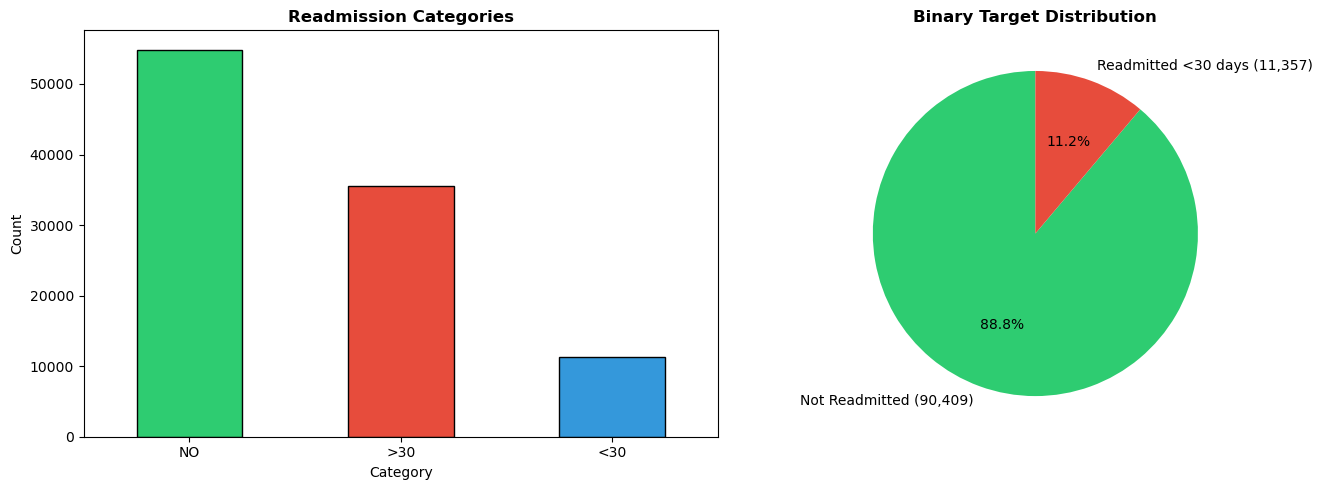

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df['readmitted'].value_counts().plot(kind='bar', ax=axes[0], color=['#2ecc71','#e74c3c','#3498db'], edgecolor='black')
axes[0].set_title('Readmission Categories', fontweight='bold')
axes[0].set_xlabel('Category')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=0)

# Right chart - binary pie chart
binary_counts = df['readmitted_binary'].value_counts().sort_index()
axes[1].pie(binary_counts.values, 
            labels=[f'Not Readmitted ({binary_counts[0]:,})', f'Readmitted <30 days ({binary_counts[1]:,})'],autopct='%1.1f%%', 
            colors=['#2ecc71', '#e74c3c'], startangle=90)
axes[1].set_title('Binary Target Distribution', fontweight='bold')

plt.tight_layout()
plt.show()

In [21]:
## Demographic Analysis

In [22]:
### Age Vs Readmission

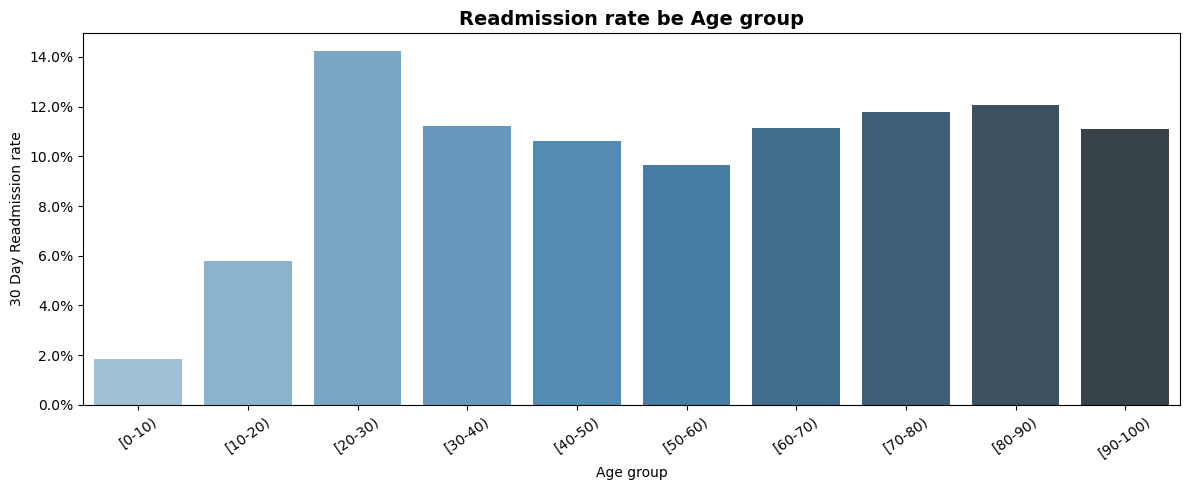

  Age Group  Readmission Rate
0    [0-10)              1.86
1   [10-20)              5.79
2   [20-30)             14.24
3   [30-40)             11.23
4   [40-50)             10.60
5   [50-60)              9.67
6   [60-70)             11.13
7   [70-80)             11.77
8   [80-90)             12.08
9  [90-100)             11.10


In [23]:
age_readmit= df.groupby('age')['readmitted_binary'].mean().reset_index()
age_readmit.columns =['Age Group', 'Readmission Rate']
age_readmit['Readmission Rate']= (age_readmit['Readmission Rate']*100).round(2)
plt.figure(figsize=(12,5))
sns.barplot(data=age_readmit, x='Age Group', y='Readmission Rate', palette='Blues_d')
plt.title('Readmission rate be Age group', fontsize=14, fontweight='bold')
plt.ylabel('30 Day Readmission rate')
plt.xlabel('Age group')
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.1f}%'))
plt.xticks(rotation =35)
plt.tight_layout()
plt.show()

print(age_readmit)

In [24]:
### Gender Vs Readmission

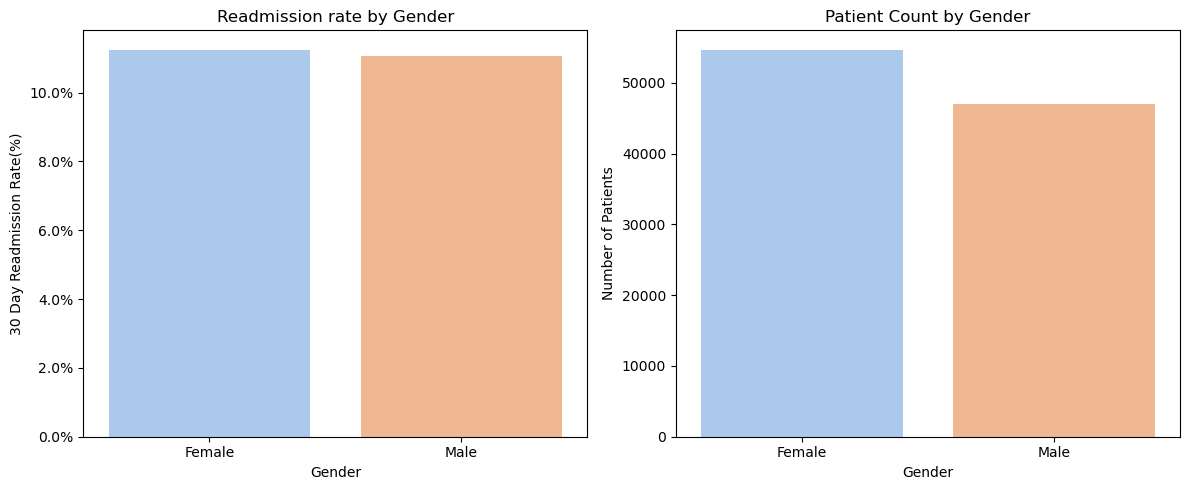

   Gender  Readmission Rate  Count
0  Female             11.25  54708
1    Male             11.06  47055


In [25]:
gender_readmit=df.groupby('gender')['readmitted_binary'].agg(['mean','count']).reset_index()
gender_readmit.columns=['Gender','Readmission Rate','Count']
gender_readmit['Readmission Rate']=(gender_readmit['Readmission Rate']*100).round(2)
gender_readmit = gender_readmit[gender_readmit['Gender'].isin(['Male', 'Female'])]

fig, axes= plt.subplots(1,2,figsize=(12,5))
sns.barplot(data=gender_readmit, x='Gender', y='Readmission Rate', palette='pastel',ax=axes[0])
axes[0].set_title('Readmission rate by Gender')
axes[0].set_ylabel('30 Day Readmission Rate(%)')
axes[0].set_xlabel('Gender')
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.1f}%'))

sns.barplot(data=gender_readmit, x='Gender', y='Count', palette='pastel',ax=axes[1])
axes[1].set_title('Patient Count by Gender')
axes[1].set_ylabel('Number of Patients')
axes[1].set_xlabel('Gender')
plt.tight_layout()
plt.show()

print(gender_readmit)


In [26]:
### Race Vs Readmission

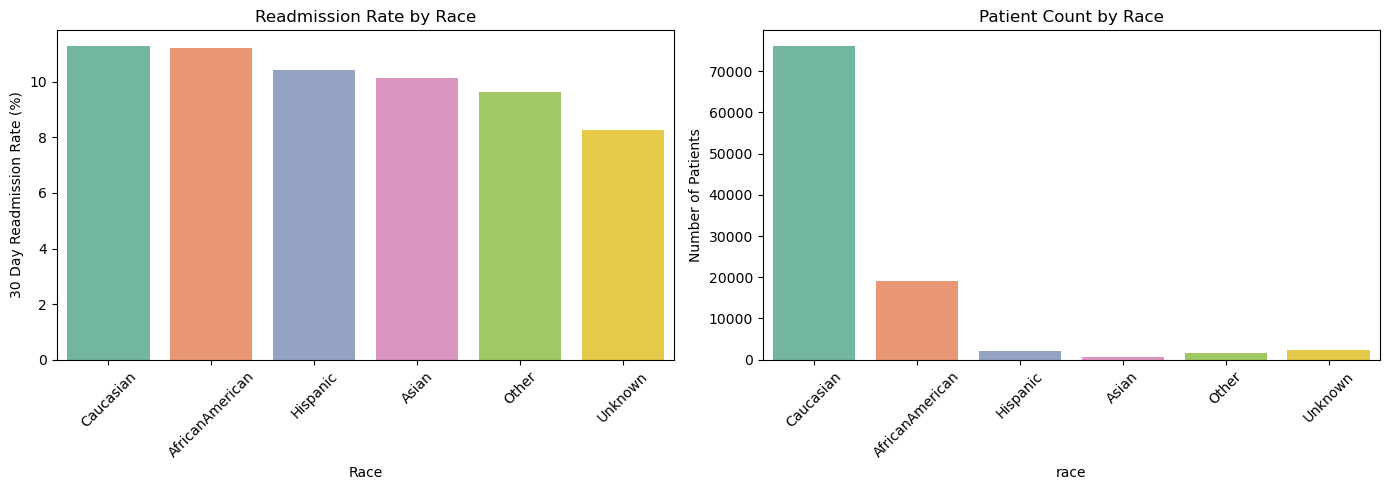

              Race  Readmission Rate  Count
0        Caucasian             11.29  76099
1  AfricanAmerican             11.22  19210
2         Hispanic             10.41   2037
3            Asian             10.14    641
4            Other              9.63   1506
5          Unknown              8.27   2273


In [27]:
race_readmit=df.groupby('race')['readmitted_binary'].agg(['mean','count']).reset_index()
race_readmit.columns=['Race','Readmission Rate','Count']
race_readmit['Readmission Rate']= (race_readmit['Readmission Rate']*100).round(2)
race_readmit= race_readmit.sort_values('Readmission Rate', ascending=False).reset_index(drop=True)

fig, axes= plt.subplots(1,2, figsize=(14,5))
sns.barplot(data=race_readmit, x='Race',y='Readmission Rate', palette='Set2',ax=axes[0])
axes[0].set_title('Readmission Rate by Race')
axes[0].set_xlabel('Race')
axes[0].set_ylabel('30 Day Readmission Rate (%)')
axes[0].tick_params(axis='x',rotation=45)

sns.barplot(data=race_readmit,x='Race',y='Count', palette ='Set2',ax=axes[1])
axes[1].set_title('Patient Count by Race')
axes[1].set_xlabel('race')
axes[1].set_ylabel('Number of Patients')
axes[1].tick_params(axis='x',rotation=45)
plt.tight_layout()
plt.show()

print(race_readmit)

In [28]:
## Clinical Analysis

In [29]:
### Readmitted Vs length of Stay

In [30]:
los_readmit=df.groupby('time_in_hospital')['readmitted_binary'].agg(['mean','count']).reset_index()
los_readmit.columns=['Days in Hospital','Readmission Rate','Count']
los_readmit['Readmission Rate']=(los_readmit['Readmission Rate']*100).round(2)
print(los_readmit)


    Days in Hospital  Readmission Rate  Count
0                  1              8.18  14208
1                  2              9.94  17224
2                  3             10.67  17756
3                  4             11.81  13924
4                  5             12.03   9966
5                  6             12.59   7539
6                  7             12.83   5859
7                  8             14.23   4391
8                  9             13.72   3002
9                 10             14.35   2342
10                11             10.51   1855
11                12             13.33   1448
12                13             12.31   1210
13                14             12.96   1042


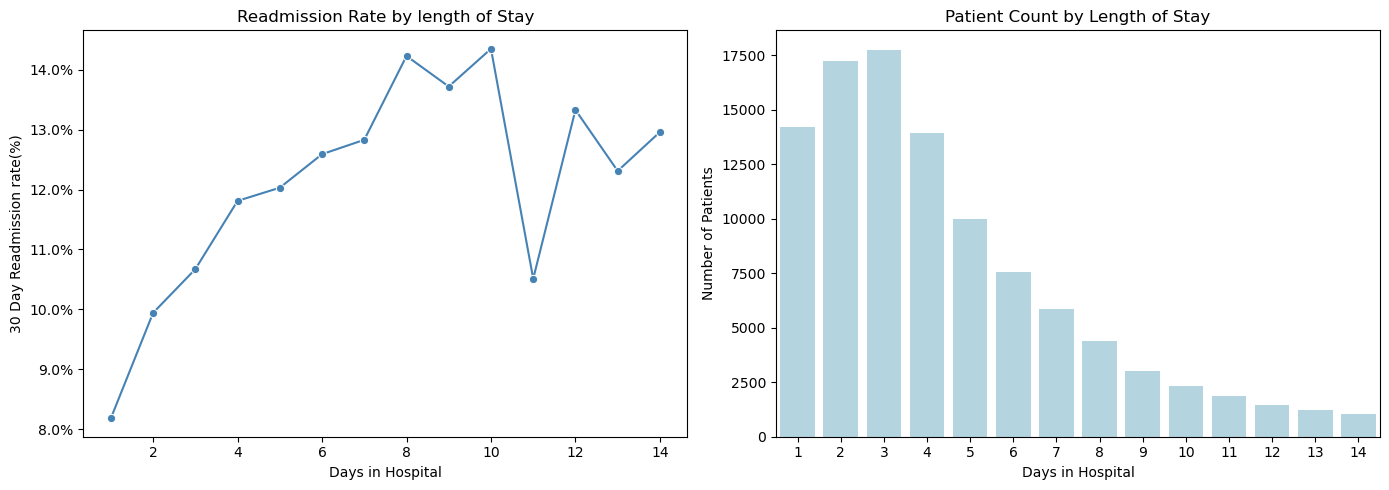

In [31]:
fig, axes=plt.subplots(1,2, figsize=(14,5))
sns.lineplot(data=los_readmit,x='Days in Hospital', y='Readmission Rate', marker='o', color='steelblue', ax=axes[0])
axes[0].set_title('Readmission Rate by length of Stay')
axes[0].set_xlabel('Days in Hospital')
axes[0].set_ylabel('30 Day Readmission rate(%)')
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.1f}%'))

sns.barplot(data=los_readmit,x='Days in Hospital',y='Count', color='lightblue',ax=axes[1])
axes[1].set_title('Patient Count by Length of Stay')
axes[1].set_xlabel('Days in Hospital')
axes[1].set_ylabel('Number of Patients')

plt.tight_layout()
plt.show()


In [32]:
### Readmitted Vs Number of Medications 

In [33]:
print(df['num_medications'].describe())
print("The total uniquie values are",df['num_medications'].nunique())

count    101766.000000
mean         16.021844
std           8.127566
min           1.000000
25%          10.000000
50%          15.000000
75%          20.000000
max          81.000000
Name: num_medications, dtype: float64
The total uniquie values are 75


In [34]:
#### The number of medications column had 75 unique values and resulted in grouping them into bins. (Note: For Healthcare data Custom binning is recommended.|Put more bins where most of your data is, wider bins where data is sparse)

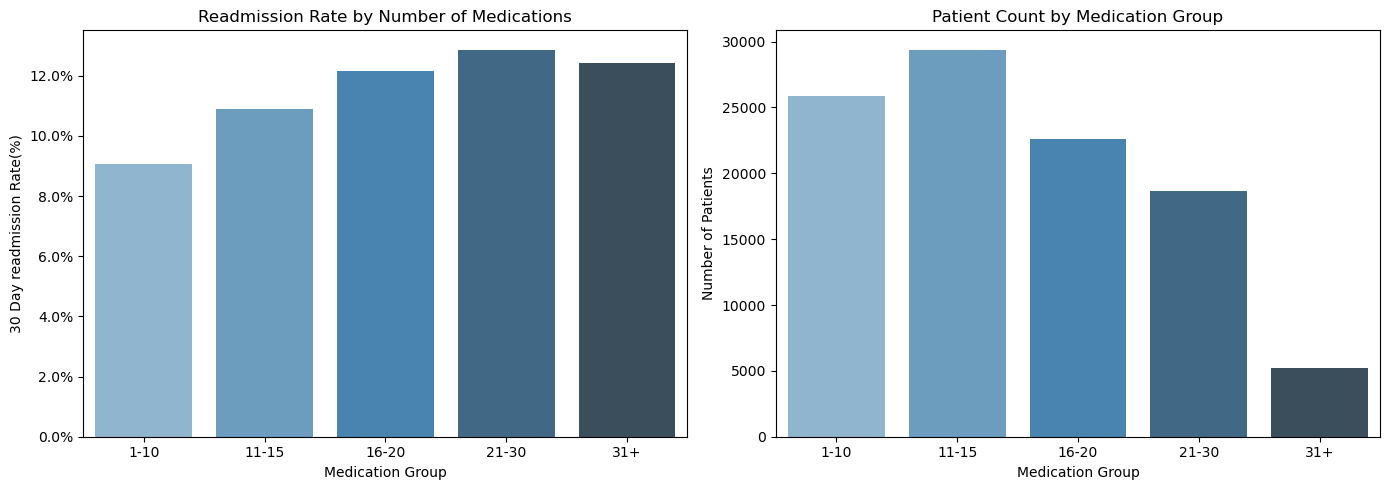

  Medication Group  Readmission Rate  Count
0             1-10              9.06  25861
1            11-15             10.91  29384
2            16-20             12.17  22641
3            21-30             12.87  18643
4              31+             12.43   5237


In [35]:
bins =[0,10,15,20,30,82]
labels= ['1-10','11-15','16-20','21-30','31+']
df['med_group']=pd.cut(df['num_medications'], bins=bins, labels=labels)

med_readmit=df.groupby('med_group')['readmitted_binary'].agg(['mean','count']).reset_index()
med_readmit.columns= ['Medication Group', 'Readmission Rate', 'Count']
med_readmit['Readmission Rate']=(med_readmit['Readmission Rate']*100).round(2)

fig, axes=plt.subplots(1,2, figsize=(14,5))

sns.barplot(data=med_readmit, x='Medication Group', y='Readmission Rate', palette='Blues_d', ax=axes[0])
axes[0].set_title('Readmission Rate by Number of Medications')
axes[0].set_xlabel('Medication Group')
axes[0].set_ylabel('30 Day readmission Rate(%)')
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.1f}%'))

sns.barplot(data=med_readmit, x='Medication Group', y='Count', palette='Blues_d', ax=axes[1])
axes[1].set_title('Patient Count by Medication Group')
axes[1].set_ylabel('Number of Patients')
axes[1].set_xlabel('Medication Group')

plt.tight_layout()
plt.show()

print(med_readmit)

In [ ]:
### Readmitted Vs Number of Lab Procedures

In [36]:
print(df['num_lab_procedures'].describe())
print(f"\n Unique Values: {df['num_lab_procedures'].nunique()}")

count    101766.000000
mean         43.095641
std          19.674362
min           1.000000
25%          31.000000
50%          44.000000
75%          57.000000
max         132.000000
Name: num_lab_procedures, dtype: float64

 Unique Values: 118


In [42]:
#### Quartile based binning

  Lab Procedures Group  Readmission Rate  Count
0            Low(1-31)         10.156005  25512
1        Medium(31-44)         11.185036  26303
2          High(45-57)         11.428460  25594
3       Very High(58+)         11.902123  24357


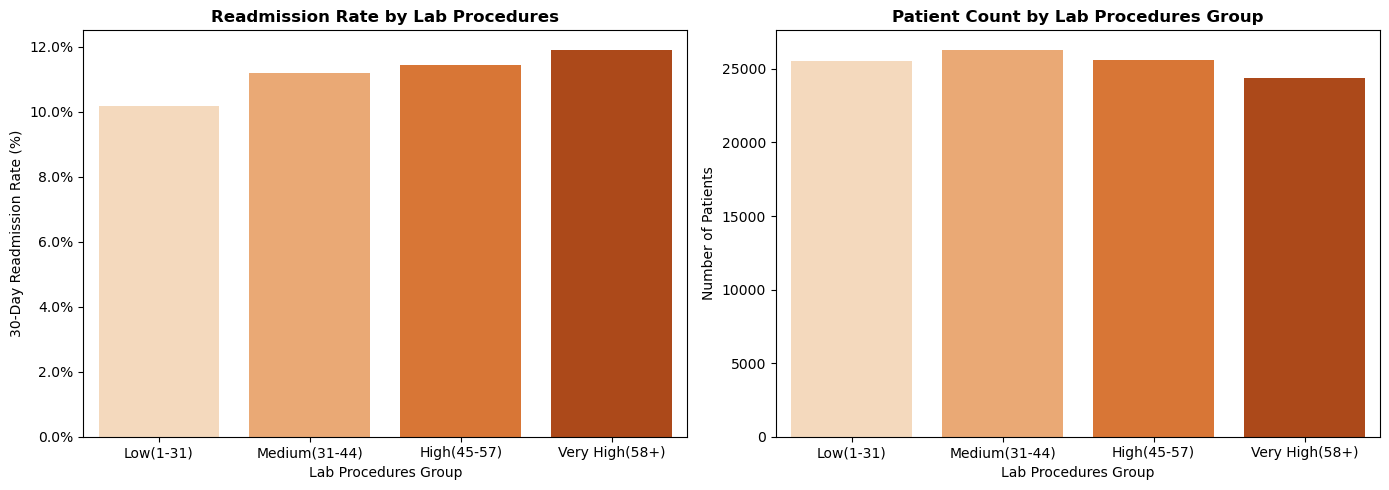

In [43]:
bins=[0,31,44,57,133]
labels=['Low(1-31)', 'Medium(31-44)', 'High(45-57)', 'Very High(58+)']
df['lab_group']=pd.cut(df['num_lab_procedures'],bins=bins, labels=labels)
lab_readmit = df.groupby('lab_group')['readmitted_binary'].agg(['mean','count']).reset_index()
lab_readmit.columns = ['Lab Procedures Group', 'Readmission Rate', 'Count']
lab_readmit['Readmission Rate'] = lab_readmit['Readmission Rate'] * 100

print(lab_readmit)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left chart - readmission rate
sns.barplot(data=lab_readmit, x='Lab Procedures Group',
            y='Readmission Rate',
            palette='Oranges', ax=axes[0])
axes[0].set_title('Readmission Rate by Lab Procedures', 
                  fontweight='bold')
axes[0].set_ylabel('30-Day Readmission Rate (%)')
axes[0].set_xlabel('Lab Procedures Group')
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.1f}%'))

# Right chart - patient count
sns.barplot(data=lab_readmit, x='Lab Procedures Group', y='Count',
            palette='Oranges', ax=axes[1])
axes[1].set_title('Patient Count by Lab Procedures Group',
                  fontweight='bold')
axes[1].set_ylabel('Number of Patients')
axes[1].set_xlabel('Lab Procedures Group')

plt.tight_layout()
plt.show()    


In [ ]:
### Readmitted vs Prior Visits Analysis(recidivism)

In [46]:
print("Inpatient Visits:")
print(df['number_inpatient'].describe())
print(f"\n Unique :{df['number_inpatient'].nunique()}")

print("\nEmergency Visits:")
print(df['number_emergency'].describe())
print(f"\n Unique :{df['number_emergency'].nunique()}")

print("\nOutpatient visits::")
print(df['number_outpatient'].describe())
print(f"\n Unique :{df['number_outpatient'].nunique()}")

Inpatient Visits:
count    101766.000000
mean          0.635566
std           1.262863
min           0.000000
25%           0.000000
50%           0.000000
75%           1.000000
max          21.000000
Name: number_inpatient, dtype: float64

 Unique :21

Emergency Visits:
count    101766.000000
mean          0.197836
std           0.930472
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max          76.000000
Name: number_emergency, dtype: float64

 Unique :33

Outpatient visits::
count    101766.000000
mean          0.369357
std           1.267265
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max          42.000000
Name: number_outpatient, dtype: float64

 Unique :39



Inpatient Visits:
   Visit Group  Readmission Rate  Count
3      None(0)              8.44  67630
1       Low(1)             12.92  19521
2  Medium(2-3)             18.32  10977
0     High(4+)             30.70   3638

Emergency Visits:
   Visit Group  Readmission Rate  Count
3      None(0)             10.47  90383
1       Low(1)             14.35   7677
2  Medium(2-3)             18.79   2767
0     High(4+)             28.54    939

Outpatient Visits:
   Visit Group  Readmission Rate  Count
3      None(0)             10.67  85027
1       Low(1)             13.92   8547
2  Medium(2-3)             13.22   5636
0     High(4+)             13.54   2556


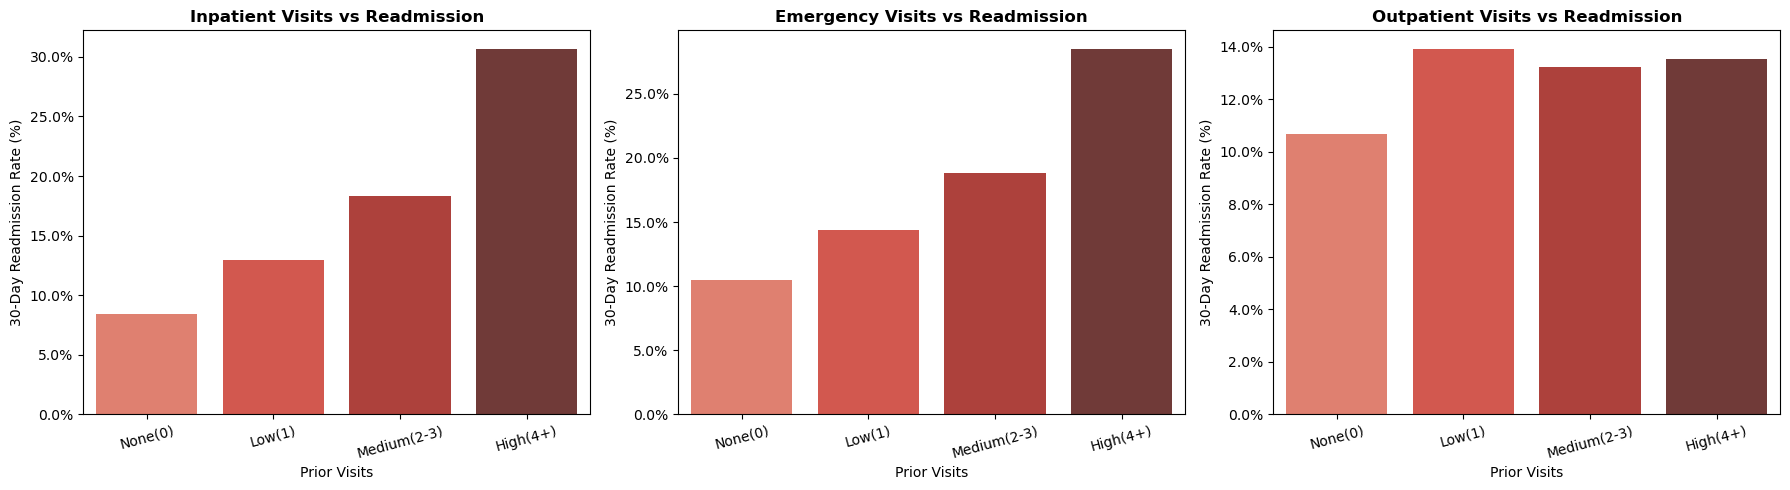

In [55]:
def categorize_visits(x):
    if x==0:
        return 'None(0)'
    elif x==1:
        return 'Low(1)'
    elif x<=3:
        return 'Medium(2-3)'
    else:
        return 'High(4+)'

df['inpatient_group'] = df['number_inpatient'].apply(categorize_visits)
df['emergency_group'] = df['number_emergency'].apply(categorize_visits)
df['outpatient_group'] = df['number_outpatient'].apply(categorize_visits)

order = ['None(0)', 'Low(1)', 'Medium(2-3)', 'High(4+)']

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, (col, title) in enumerate([
    ('inpatient_group', 'Inpatient'),
    ('emergency_group', 'Emergency'),
    ('outpatient_group', 'Outpatient')
]):
    visit_readmit = df.groupby(col)['readmitted_binary'].agg(['mean', 'count']).reset_index()
    visit_readmit.columns = ['Visit Group', 'Readmission Rate', 'Count']
    visit_readmit['Readmission Rate'] = (visit_readmit['Readmission Rate'] * 100).round(2)
    visit_readmit['Visit Group'] = pd.Categorical(visit_readmit['Visit Group'], 
                                                   categories=order, 
                                                   ordered=True)
    visit_readmit = visit_readmit.sort_values('Visit Group')
    
    sns.barplot(data=visit_readmit, x='Visit Group', y='Readmission Rate',
                palette='Reds_d', ax=axes[i])
    axes[i].set_title(f'{title} Visits vs Readmission', fontweight='bold')
    axes[i].set_ylabel('30-Day Readmission Rate (%)')
    axes[i].set_xlabel('Prior Visits')
    axes[i].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.1f}%'))
    axes[i].tick_params(axis='x', rotation=15)
    
    print(f"\n{title} Visits:")
    print(visit_readmit)

plt.tight_layout()
plt.show()
    

In [ ]:
### Readmitted vs Diagnosis Group

In [57]:
print(df['diag_1'].describe())


count     101766
unique       717
top          428
freq        6862
Name: diag_1, dtype: object


In [60]:
###The official ICD-9 number ranges:
    ####RangeCategory        Example diseases
    ####390-459              Circulatory(Heart attack, stroke, hypertension)
    ####460-519              Respiratory(Pneumonia, asthma, COPD)
    ####520-579              Digestive(Ulcers, liver disease, colitis)
    ####250.xx               Diabetes(Type 1, Type 2, complications)
    ####800-999              Injury(Fractures, poisoning, trauma)
    ####710-739              Musculoskeletal(Arthritis, back pain, bone disease)
    ####580-629              Genitourinary(Kidney disease, UTI)
    ####140-239              Neoplasms(Cancers and tumors)
    ####V codes              OtherPreventive care, follow ups
    ####E codes              OtherExternal causes like accidents

In [61]:
def group_diagnosis(code):
    try:
        # Handle special codes starting with V or E
        c = str(code)
        if c.startswith('V') or c.startswith('E'):
            return 'Other'
            
        num = float(c)
        
        if 390 <= num <= 459 or num == 785:
            return 'Circulatory'
        elif 460 <= num <= 519 or num == 786:
            return 'Respiratory'
        elif 520 <= num <= 579 or num == 787:
            return 'Digestive'
        elif str(code).startswith('250'):
            return 'Diabetes'
        elif 800 <= num <= 999:
            return 'Injury'
        elif 710 <= num <= 739:
            return 'Musculoskeletal'
        elif 580 <= num <= 629 or num == 788:
            return 'Genitourinary'
        elif 140 <= num <= 239:
            return 'Neoplasms'
        else:
            return 'Other'
    except:
        return 'Other'

df['diag_1_group'] = df['diag_1'].apply(group_diagnosis)

print("Diagnosis Groups:")
print(df['diag_1_group'].value_counts())

Diagnosis Groups:
diag_1_group
Circulatory        30437
Other              18193
Respiratory        14423
Digestive           9475
Diabetes            8757
Injury              6974
Genitourinary       5117
Musculoskeletal     4957
Neoplasms           3433
Name: count, dtype: int64


   Diagnosis Group  Readmission Rate  Count
0         Diabetes             12.98   8757
1           Injury             12.25   6974
2            Other             11.49  18193
3      Circulatory             11.45  30437
4    Genitourinary             10.85   5117
5        Digestive             10.71   9475
6        Neoplasms             10.08   3433
7      Respiratory              9.73  14423
8  Musculoskeletal              9.50   4957


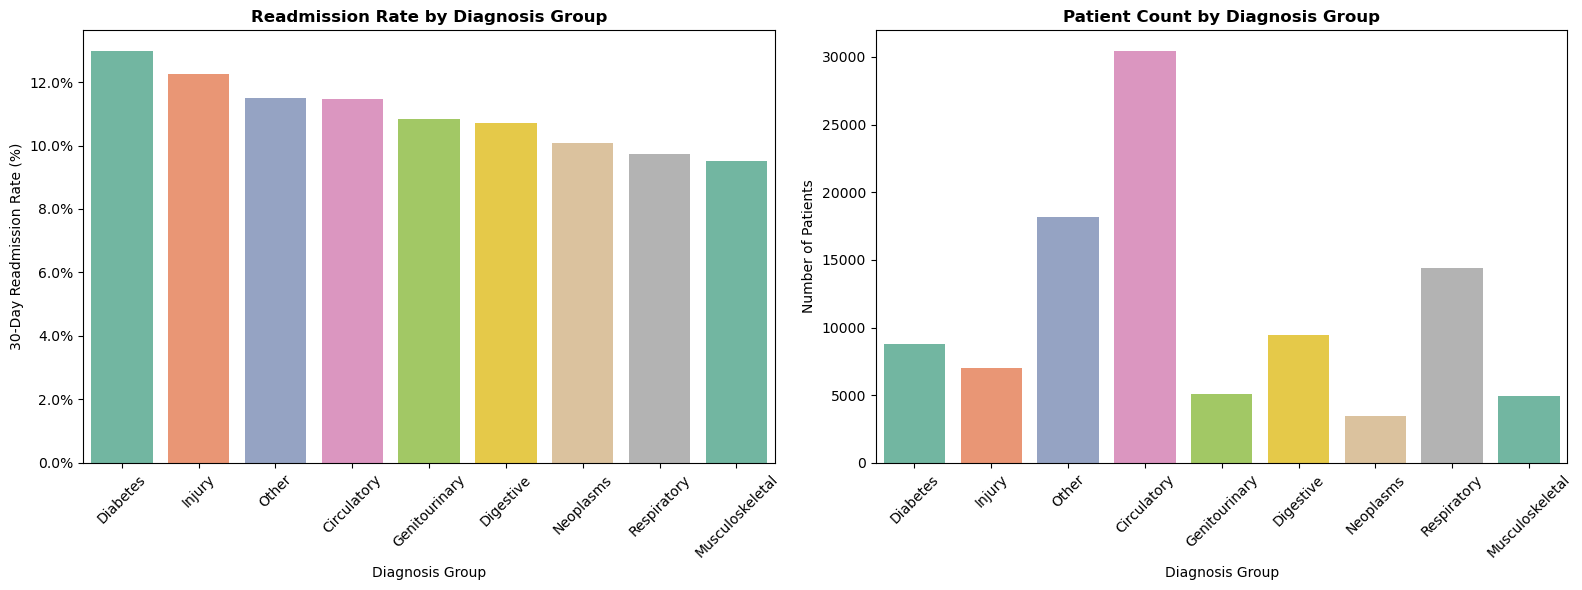

In [63]:
diag_readmit = df.groupby('diag_1_group')['readmitted_binary'].agg(['mean', 'count']).reset_index()
diag_readmit.columns = ['Diagnosis Group', 'Readmission Rate', 'Count']
diag_readmit['Readmission Rate'] = (diag_readmit['Readmission Rate'] * 100).round(2)

# Sort by readmission rate
diag_readmit = diag_readmit.sort_values('Readmission Rate', ascending=False).reset_index(drop=True)

print(diag_readmit)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.barplot(data=diag_readmit, x='Diagnosis Group', y='Readmission Rate',palette='Set2', ax=axes[0])
axes[0].set_title('Readmission Rate by Diagnosis Group', fontweight='bold')
axes[0].set_ylabel('30-Day Readmission Rate (%)')
axes[0].set_xlabel('Diagnosis Group')
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.1f}%'))
axes[0].tick_params(axis='x', rotation=45)

sns.barplot(data=diag_readmit, x='Diagnosis Group', y='Count',palette='Set2', ax=axes[1])
axes[1].set_title('Patient Count by Diagnosis Group', fontweight='bold')
axes[1].set_ylabel('Number of Patients')
axes[1].set_xlabel('Diagnosis Group')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

In [ ]:
## Correlation Heatmap

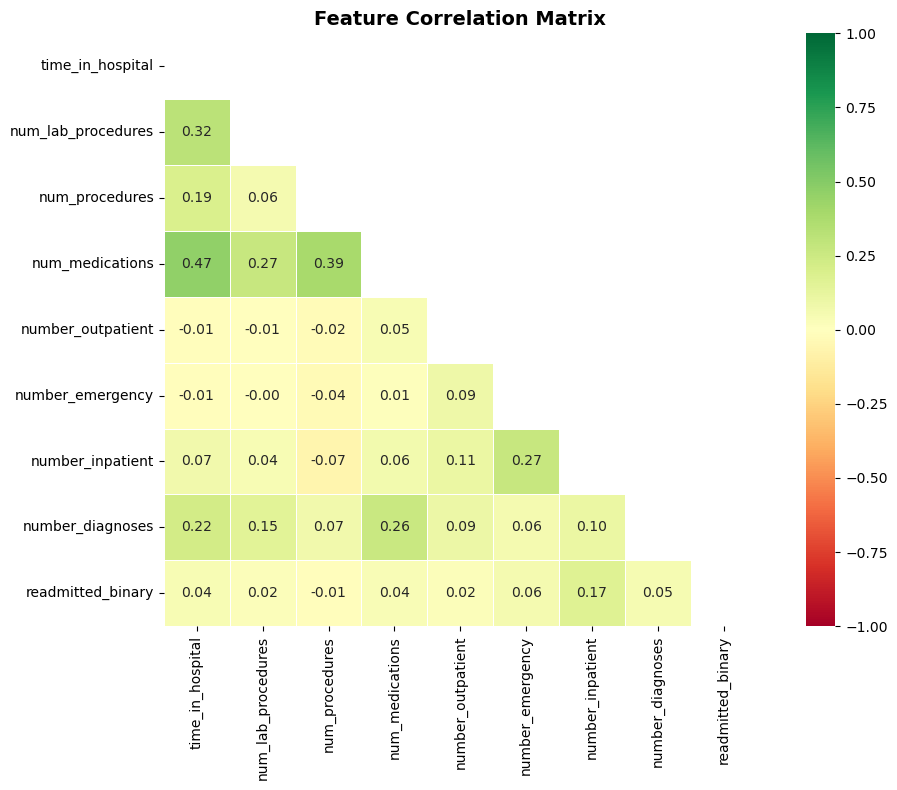

In [64]:
numeric_cols = ['time_in_hospital', 'num_lab_procedures','num_procedures', 'num_medications',
                'number_outpatient', 'number_emergency','number_inpatient', 'number_diagnoses','readmitted_binary']
corr_matrix = df[numeric_cols].corr()

plt.figure(figsize=(11, 8))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, 
            annot=True, 
            fmt='.2f', 
            cmap='RdYlGn',
            mask=mask, 
            vmin=-1, 
            vmax=1, 
            square=True,
            linewidths=0.5)
plt.title('Feature Correlation Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [65]:
#### Note: Low correlation values do not mean weak predictors! Bar chart analysis revealed number_inpatient has a 263%  increase in readmission rate from 0 to 4+ visits, a non-linear pattern invisible to correlation analysis

In [67]:
print("=" * 60)
print("EDA COMPLETE — KEY FINDINGS SUMMARY")
print("=" * 60)

print(f"""
DATASET:
  Total encounters    : {len(df):,}
  Features analyzed   : {df.shape[1]}
  30-day readmission  : {df['readmitted_binary'].mean()*100:.1f}%

DEMOGRAPHIC FINDINGS:
  Age     → Young adults (20-30) highest risk at 14.24%
  Gender  → Not a strong predictor (Male 11.06% vs Female 11.25%)
  Race    → Caucasians dominate volume (76,099 patients)

CLINICAL FINDINGS:
  Strongest predictors identified:
  1. Prior inpatient visits → 8.44% to 30.70% (263% increase!)
  2. Number of medications  → 9.06% to 12.87% (monotonic)
  3. Length of stay         → 8.18% to 14.35% (monotonic)
  4. Emergency visits       → 10.47% to 28.54% (173% increase)
  5. Diagnosis group        → Diabetes highest rate (12.98%)
  
  Weakest predictors:
  - Outpatient visits (flat after 1 visit)
  - Gender (0.19% difference)
  - Lab procedures (weakest monotonic signal)

NEXT STEPS:
  Notebook 02 → Feature Engineering
  Notebook 03 → ML Modeling (Random Forest + XGBoost)
  Notebook 04 → Business Insights + Recommendations
""")


EDA COMPLETE — KEY FINDINGS SUMMARY

DATASET:
  Total encounters    : 101,766
  Features analyzed   : 52
  30-day readmission  : 11.2%

DEMOGRAPHIC FINDINGS:
  Age     → Young adults (20-30) highest risk at 14.24%
  Gender  → Not a strong predictor (Male 11.06% vs Female 11.25%)
  Race    → Caucasians dominate volume (76,099 patients)

CLINICAL FINDINGS:
  Strongest predictors identified:
  1. Prior inpatient visits → 8.44% to 30.70% (263% increase!)
  2. Number of medications  → 9.06% to 12.87% (monotonic)
  3. Length of stay         → 8.18% to 14.35% (monotonic)
  4. Emergency visits       → 10.47% to 28.54% (173% increase)
  5. Diagnosis group        → Diabetes highest rate (12.98%)

  Weakest predictors:
  - Outpatient visits (flat after 1 visit)
  - Gender (0.19% difference)
  - Lab procedures (weakest monotonic signal)

NEXT STEPS:
  Notebook 02 → Feature Engineering
  Notebook 03 → ML Modeling (Random Forest + XGBoost)
  Notebook 04 → Business Insights + Recommendations

